In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import plot_tree

In [2]:
df= pd.read_csv("loan.csv")
df.sample(5)

,Applicant,Age,Income,Credit_Score,Loan_Approved
257,258,Old,High,Bad,No
212,213,Middle,Low,Bad,No
199,200,Old,Low,Bad,Yes
194,195,Old,Low,Bad,No
156,157,Middle,Low,Bad,No


In [3]:
X= df.iloc[:, 1:4]
y= df.iloc[:, -1]

# Train Test Split

In [4]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

# Encoding Data

In [5]:
oe = OrdinalEncoder(categories= [['Young', 'Middle', 'Old'], ['Low', 'Medium', 'High'], ['Bad', 'Good']], dtype= np.int32)
X_train_new= oe.fit_transform(X_train)
X_test_new= oe.transform(X_test)

le= LabelEncoder()
y_train_new= le.fit_transform(y_train)
y_test_new= le.transform(y_test)

In [6]:
X_train_new= pd.DataFrame(X_train_new, columns= oe.get_feature_names_out())
X_test_new= pd.DataFrame(X_test_new, columns= oe.get_feature_names_out())
X_train_new.sample(5)

,Age,Income,Credit_Score
238,2,1,1
67,2,2,0
177,2,2,1
111,2,1,1
83,2,0,1


# Model Selection

In [7]:
model= RandomForestClassifier(max_depth=2, random_state=42, n_estimators=100)
model.fit(X_train_new, y_train_new)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [8]:
y_pred= model.predict(X_test_new)
print(y_pred)
print("\n\n", y_test_new)

[0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 0 0 0 0 0
 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 0]


 [0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 0 0 1 1
 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 0]


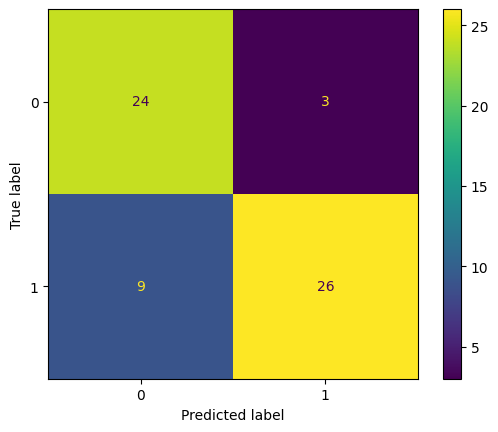

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test_new, y_pred)
plt.show()

In [10]:
print(classification_report(y_test_new, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.89      0.80        27
           1       0.90      0.74      0.81        35

    accuracy                           0.81        62
   macro avg       0.81      0.82      0.81        62
weighted avg       0.82      0.81      0.81        62



# Decision Tree Visualization

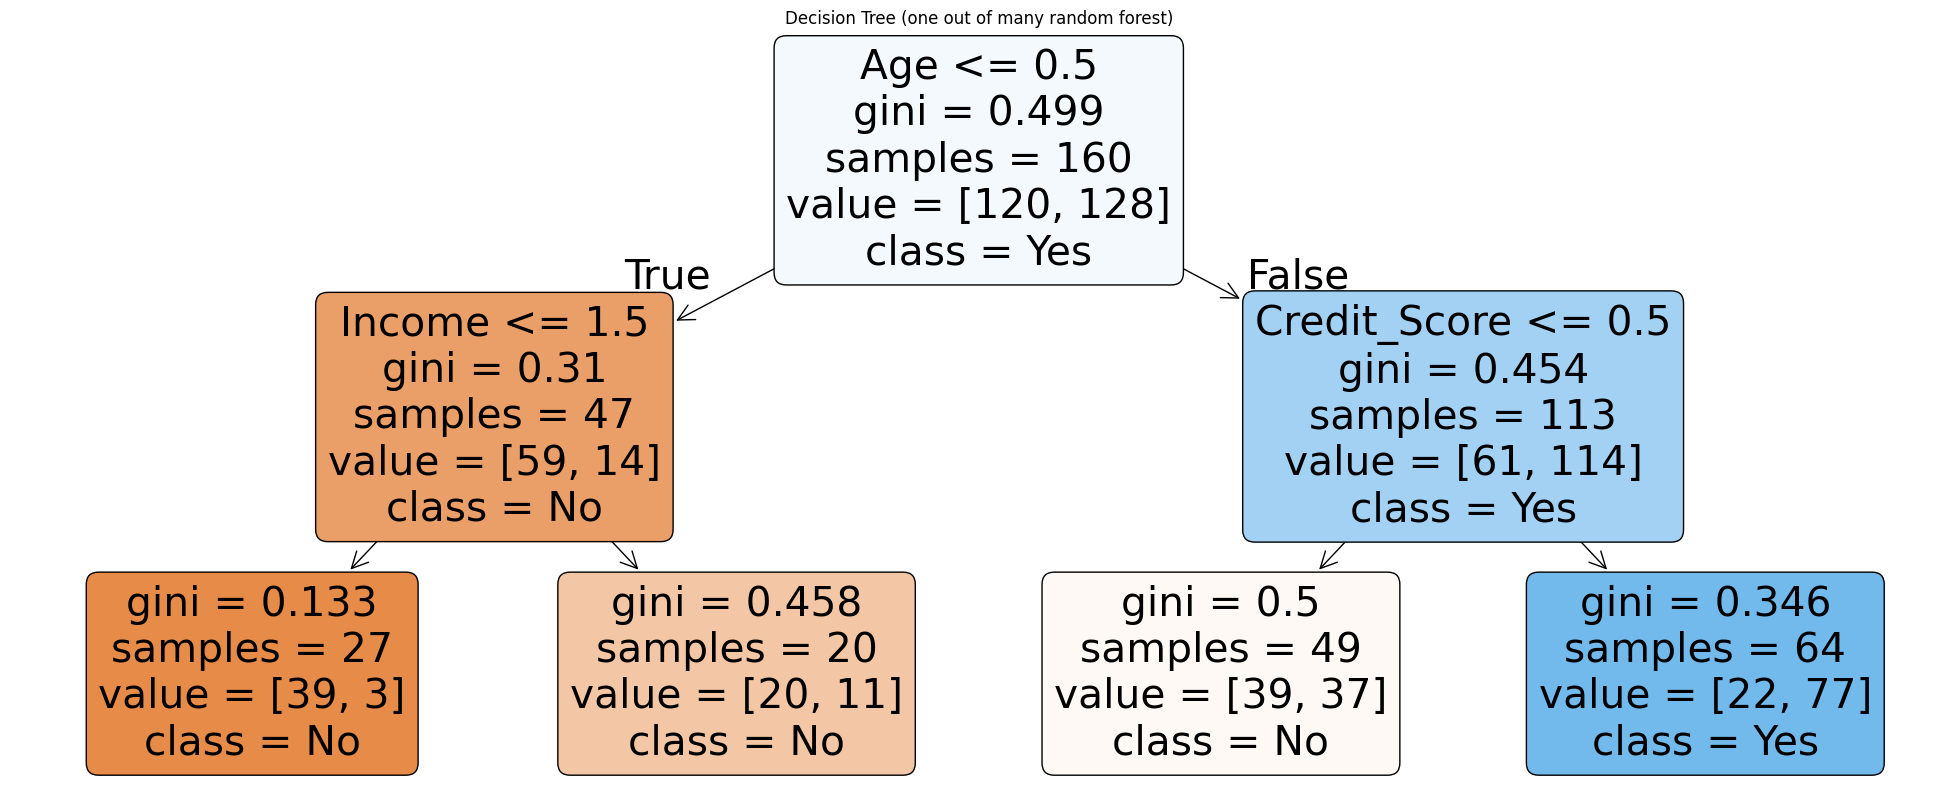

In [11]:
plt.figure(figsize=(25,10))
tree= model.estimators_[0]
plot_tree(tree, filled= True, rounded= True, feature_names=oe.get_feature_names_out(),  class_names=le.classes_)
plt.title("Decision Tree (one out of many random forest)")
plt.show()

# Feature Importance

In [19]:
imp= model.feature_importances_
feature_names= oe.get_feature_names_out()
for name, score in zip(feature_names, imp):
    print(name, ":", np.round(score, 2))

Age : 0.39
Income : 0.49
Credit_Score : 0.12


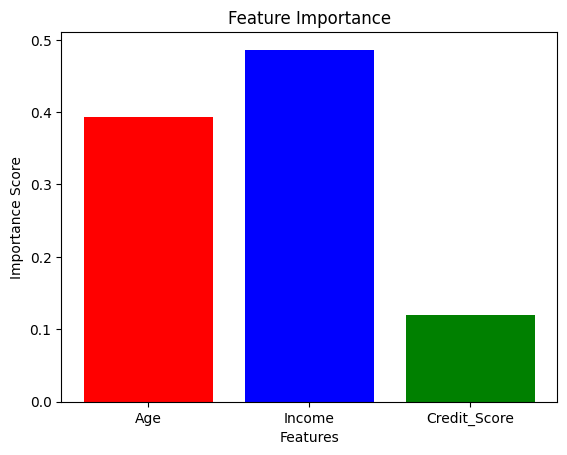

In [28]:
plt.bar(feature_names, imp, color=['red', 'blue', 'green'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()